#Seasonal Agriculture Performance Analysis

## Major Data Analytics Project

**Domain:** Agriculture  
**Project Theme:** Seasonal Agriculture Performance  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

### Project Goal
The main goal of this project is to analyze agricultural data across different seasons and identify meaningful patterns, trends, relationships, and variations in agricultural performance.

## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.
However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.

The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.

## 2. Project Objectives

- Understand the structure and quality of the agricultural dataset.
- Clean and prepare the data for analysis.
- Explore seasonal patterns in the dataset.
- Perform descriptive and statistical analysis.
- Investigate relationships among relevant variables.
- Compare agricultural performance across seasons and other meaningful groups.
- Use appropriate univariate, bivariate and multivariate visualizations.
- Identify significant findings from the data.
- Develop evidence-based insights and recommendations.


## 3. Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

**Dataset file:** `/content/seasonal_agriculture_performance_dataset.csv`

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load the dataset

df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


# 4. Initial Data Understanding

In [ ]:
# Dataset shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [ ]:
# top 5
df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
# Bpttom 5
df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [ ]:
# Random sample of records
df.sample(6, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.8,25.3,47.7,7.6,...,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.545,34.4
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.9,27.2,60.2,8.3,...,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.009,31.8
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.7,26.3,73.6,7.1,...,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.654,52.7
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.0,17.9,59.7,9.4,...,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.293,29.8
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.8,19.0,55.8,9.2,...,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.363,39.6
70,SF10071,Maharashtra,Krishna,Cotton,Rabi,14.72,338.5,21.2,68.5,7.7,...,0.84,1.00,14.72,61717,960387,908474,-51913,9888,1.489,35.8


In [ ]:
# Column names

print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [ ]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
# Check the data type of each column
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [ ]:
# Numerical summary statistics

df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [ ]:
# Categorical summary

df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


## 5. Missing Value Analysis and Handling

Missing values can affect statistical analysis and visualizations. Therefore,
the dataset is checked for missing observations before proceeding with further
analysis. The missing values are identified, measured, and handled using
appropriate methods.

In [ ]:
# Check the number of missing values in each column
missing_values = df.isnull().sum()
missing_values

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
# Percentage of missing values in each column
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_summary = pd.DataFrame({
    'Missing_Values': df.isnull().sum(),
    'Missing_Percentage': missing_percentage
})
missing_summary[missing_summary['Missing_Values'] > 0]

,Missing_Values,Missing_Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


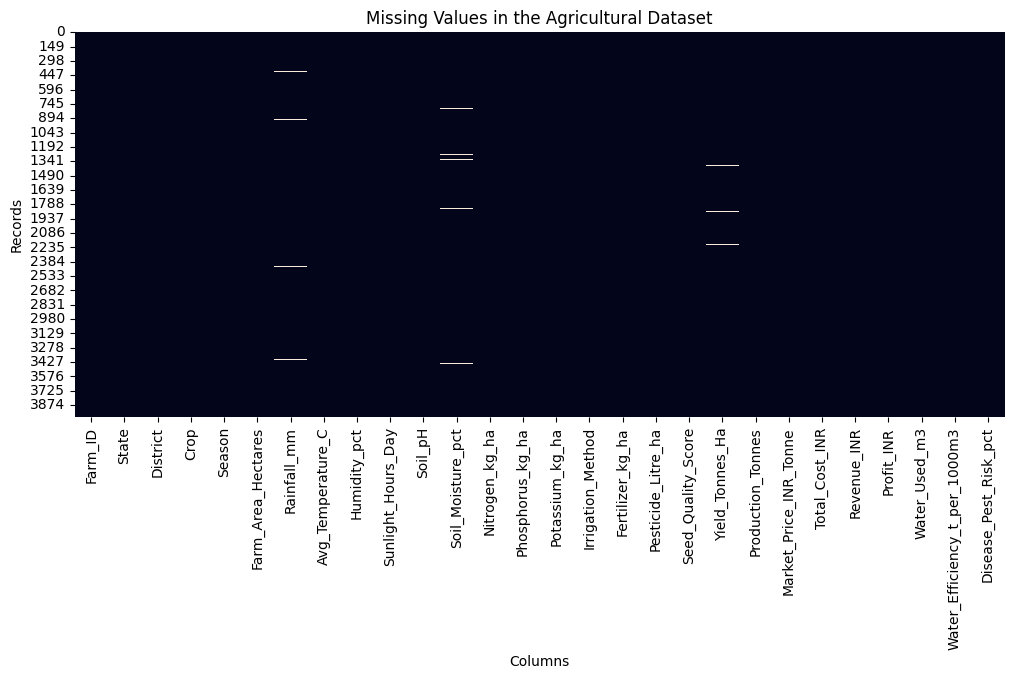

In [ ]:
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values in the Agricultural Dataset')
plt.xlabel('Columns')
plt.ylabel('Records')
plt.show()

In [ ]:
# Fill missing numerical values using the median
numerical_columns = df.select_dtypes(include=np.number).columns
for col in numerical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [ ]:
# Fill missing categorical values using the mode
categorical_columns = df.select_dtypes(include='object').columns
for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
print("Total missing values remaining:", df.isnull().sum().sum())

Total missing values remaining: 0


## 6. Duplicate Record Analysis

Duplicate records can affect statistical results by giving extra weight to
repeated observations. Therefore, duplicate rows are identified and removed
before continuing with the analysis.

In [ ]:
# Duplicate rows in the dataset
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## 7. Descriptive and Statistical Analysis

Descriptive statistics are used to understand the central tendency,
spread, and overall variation of the numerical agricultural variables.

In [ ]:
# Descriptive statistics for numerical variables
numeric_columns = df.select_dtypes(include=np.number).columns
stats = df[numeric_columns].describe().T
stats["Range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]
stats.round(2)

,count,mean,std,min,25%,50%,75%,max,Range,IQR
Farm_Area_Hectares,4000.0,7.89,4.22,0.50,4.26,7.90,11.65,15.00,14.50,7.39
Rainfall_mm,4000.0,600.92,287.19,80.00,371.58,582.00,831.98,1395.20,1315.20,460.40
Avg_Temperature_C,4000.0,26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,4000.0,63.21,11.96,25.00,54.78,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,4000.0,7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,4000.0,6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,4000.0,26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,4000.0,120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,4000.0,57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,4000.0,104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [ ]:
# Statistical measures
statistical_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Standard_Deviation": df[numeric_columns].std(),
    "Minimum": df[numeric_columns].min(),
    "Maximum": df[numeric_columns].max()
})
statistical_summary.round(2)

,Mean,Median,Standard_Deviation,Minimum,Maximum
Farm_Area_Hectares,7.89,7.90,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,1395.20
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [ ]:
# Seasonal descriptive summary
season_summary = df.groupby("Season")[numeric_columns].agg(["mean", "median", "std"])
season_summary

Farm_Area_Hectares                  Rainfall_mm                     \
                     mean median       std        mean median         std   
Season                                                                      
Kharif           7.944924  8.180  4.282328  849.199663  853.1  183.686045   
Rabi             7.752207  7.680  4.179402  437.615366  432.2  175.351345   
Zaid             8.091246  8.085  4.162594  304.654714  288.2  157.238490   

       Avg_Temperature_C                  Humidity_pct  ...     Profit_INR  \
                    mean median       std         mean  ...            std   
Season                                                  ...                  
Kharif         28.454019   28.5  2.510166    71.812591  ...  611549.783883   
Rabi           23.489183   23.5  2.459561    57.893178  ...  489901.254255   
Zaid           31.042088   31.0  2.554911    52.012121  ...  436356.747261   

       Water_Used_m3                      Water_Efficiency_t_per_1000m3  \
                mean  median          std                          mean   
Season                                                                    
Kharif   6102.201237  4469.0  5670.582696                      5.891834   
Rabi     5846.987093  4292.0  5397.648066                      5.186122   
Zaid     6419.893939  4805.0  5734.619854                      4.413239   

                         Disease_Pest_Risk_pct                    
        median       std                  mean median        std  
Season                                                            
Kharif  3.2770  9.833333             54.467903   54.5  10.087931  
Rabi    2.7400  8.258037             40.482114   40.6  10.104157  
Zaid    2.3015  6.930111             38.216667   37.9   9.873938  

[3 rows x 66 columns]

## 8. Outlier Analysis

Outliers are unusually high or low observations that may influence the
results of statistical analysis.
These observations are investigated rather than automatically removed,
because extreme agricultural values may represent genuine conditions.

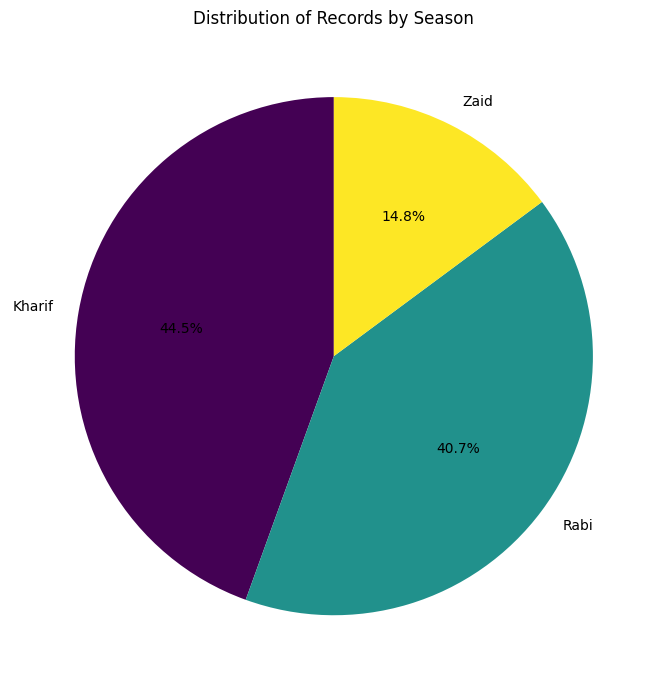

In [ ]:
plt.figure(figsize=(7, 7))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Distribution of Records by Season')
plt.ylabel('') # Hide the default 'Season' label on the y-axis
plt.tight_layout()
plt.show()

In [ ]:
# IQR-based outlier summary for numerical columns

outlier_summary = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": count,
        "Outlier_Percentage": round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    "Outlier_Count", ascending=False
)
outlier_summary

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,-696111.000000,7.635670e+05,404,10.10
14,Production_Tonnes,-23.982500,5.335750e+01,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.572875,1.038412e+01,322,8.05
13,Yield_Tonnes_Ha,-1.620000,5.500000e+00,302,7.55
19,Water_Used_m3,-6072.750000,1.617125e+04,276,6.90
17,Revenue_INR,-736519.000000,1.780911e+06,240,6.00
9,Potassium_kg_ha,30.100000,1.797000e+02,32,0.80
4,Sunlight_Hours_Day,4.350000,1.035000e+01,26,0.65
8,Phosphorus_kg_ha,11.400000,1.042000e+02,16,0.40
10,Fertilizer_kg_ha,19.137500,3.520375e+02,15,0.38


## 9. Univariate Analysis

Univariate analysis examines one variable at a time to understand its
distribution, frequency, central tendency, and variation.

The analysis focuses on important categorical and numerical variables
related to agricultural production and performance.

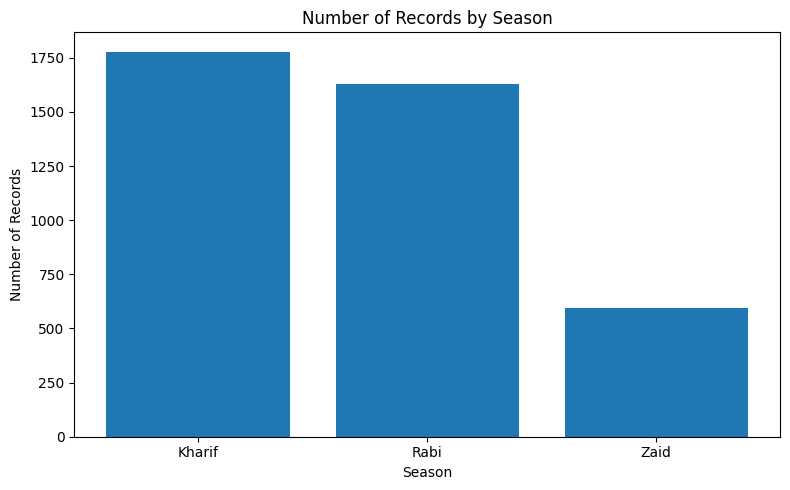

In [ ]:
# Distribution of agricultural records across seasons

season_counts = df["Season"].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(season_counts.index, season_counts.values)
plt.title("Number of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

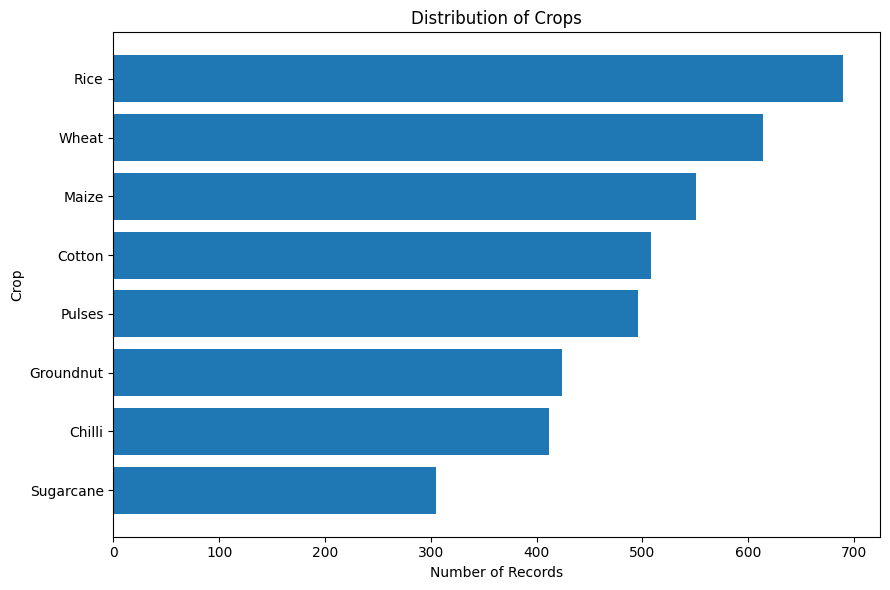

In [ ]:
# Distribution of records across different crops
crop_counts = df["Crop"].value_counts().sort_values()
plt.figure(figsize=(9, 6))
plt.barh(crop_counts.index, crop_counts.values)
plt.title("Distribution of Crops")
plt.xlabel("Number of Records")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

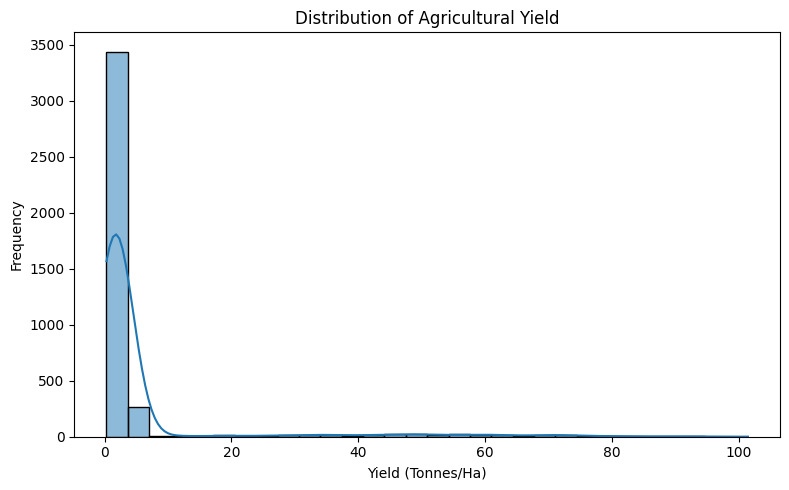

In [ ]:
# Distribution of agricultural yield

plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="Yield_Tonnes_Ha",
    bins=30,
    kde=True
)
plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

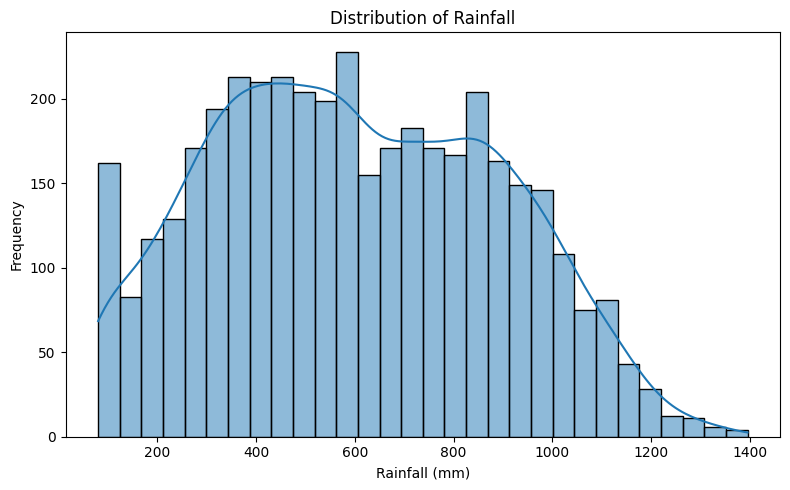

In [ ]:
# Distribution of rainfall
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="Rainfall_mm",
    bins=30,
    kde=True
)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 10. Bivariate Analysis

Bivariate analysis examines the relationship between two variables.

The analysis focuses on relationships between season,
agricultural performance, environmental conditions, resource usage,
and production.

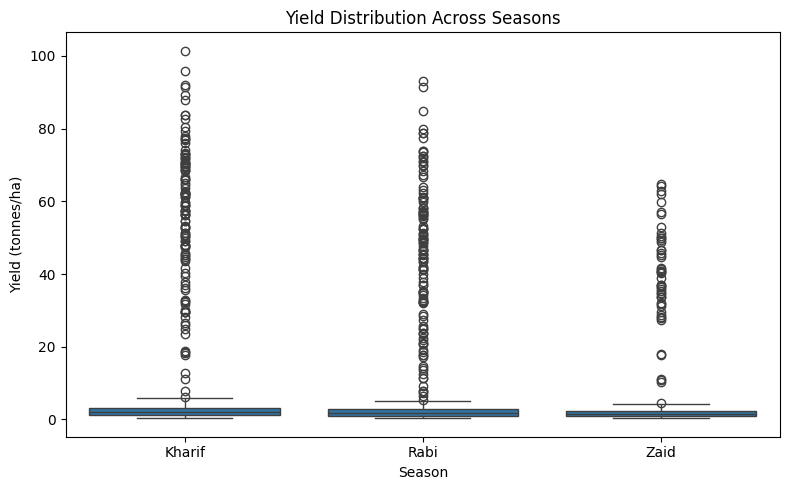

In [ ]:
#  Season vs Yield
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

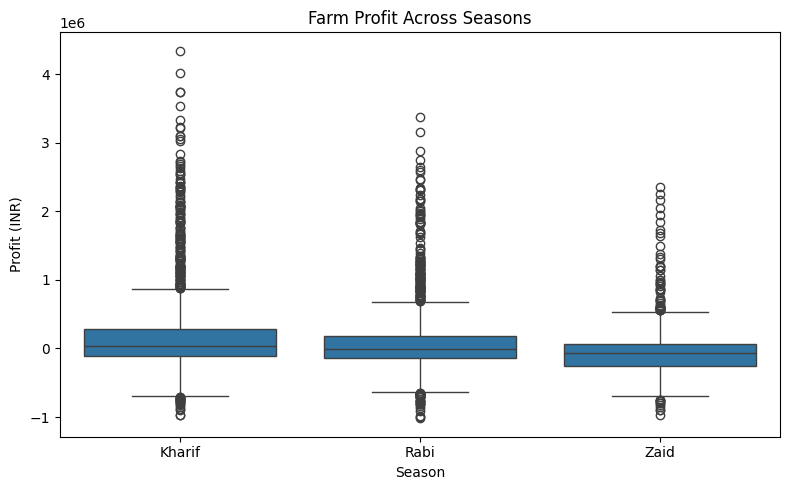

In [ ]:
# Season vs Profit
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Profit_INR")
plt.title("Farm Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

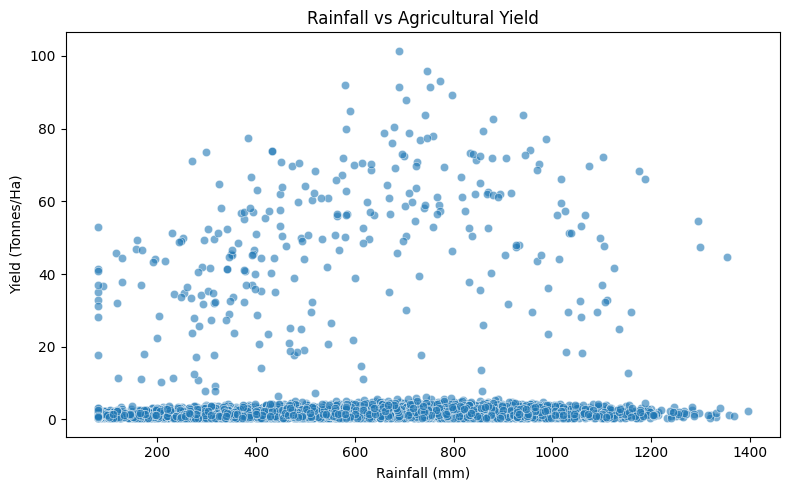

In [ ]:
# Rainfall vs Yield
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    alpha=0.6
)
plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

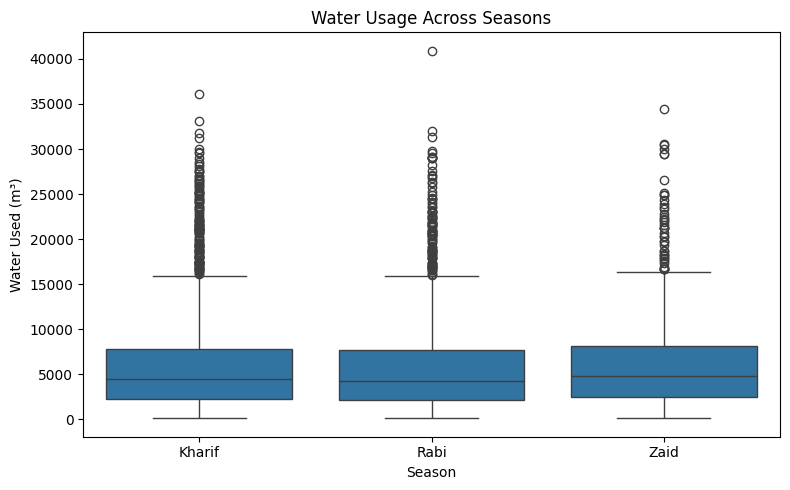

In [ ]:
# Season vs Water Usage
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Season",
    y="Water_Used_m3"
)
plt.title("Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.tight_layout()
plt.show()

## 11. Multivariate Analysis

Multivariate analysis examines more than two variables simultaneously.

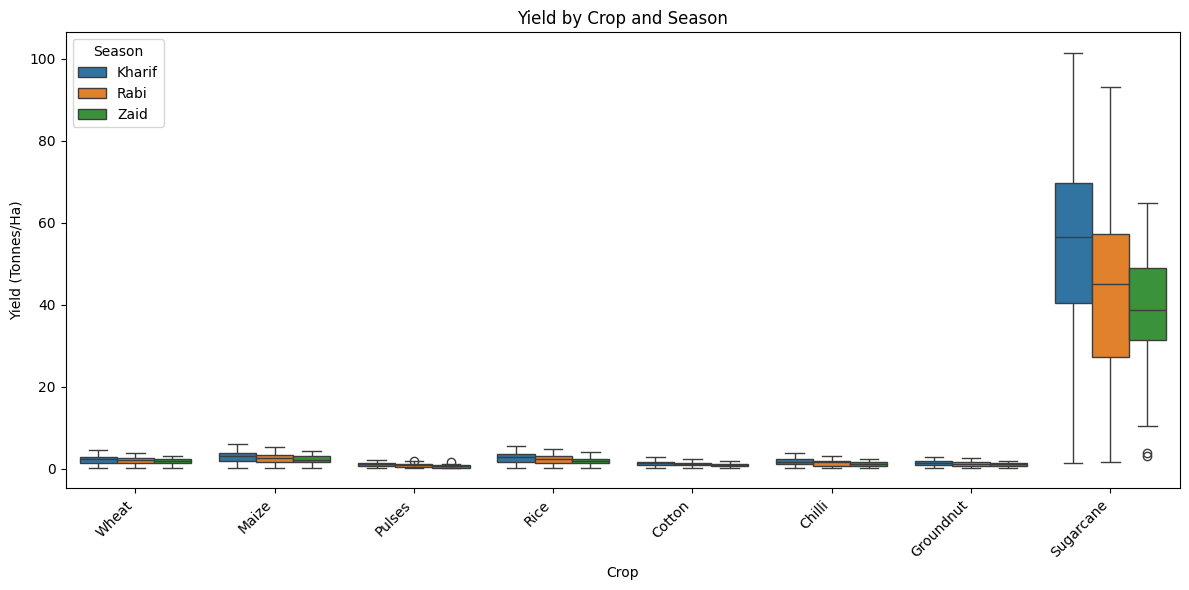

In [ ]:
# Yield across crops and seasons
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="Crop",
    y="Yield_Tonnes_Ha",
    hue="Season"
)
plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

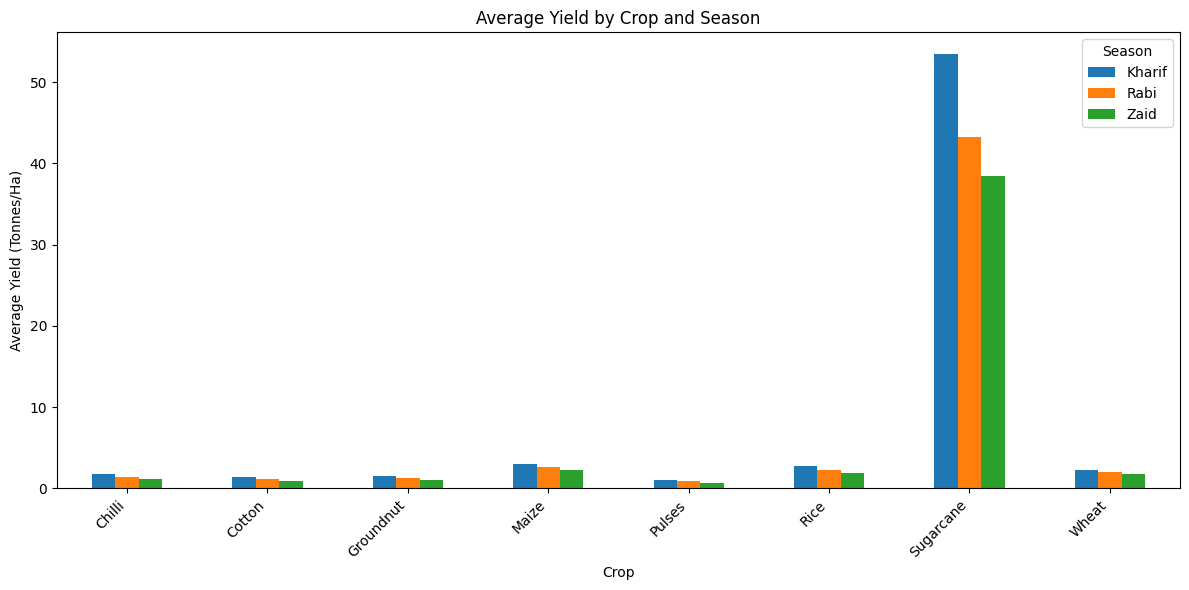

In [ ]:
# Average yield for each crop and season
avg_yield = df.pivot_table(
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)
avg_yield.plot(kind="bar", figsize=(12, 6))
plt.title("Average Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

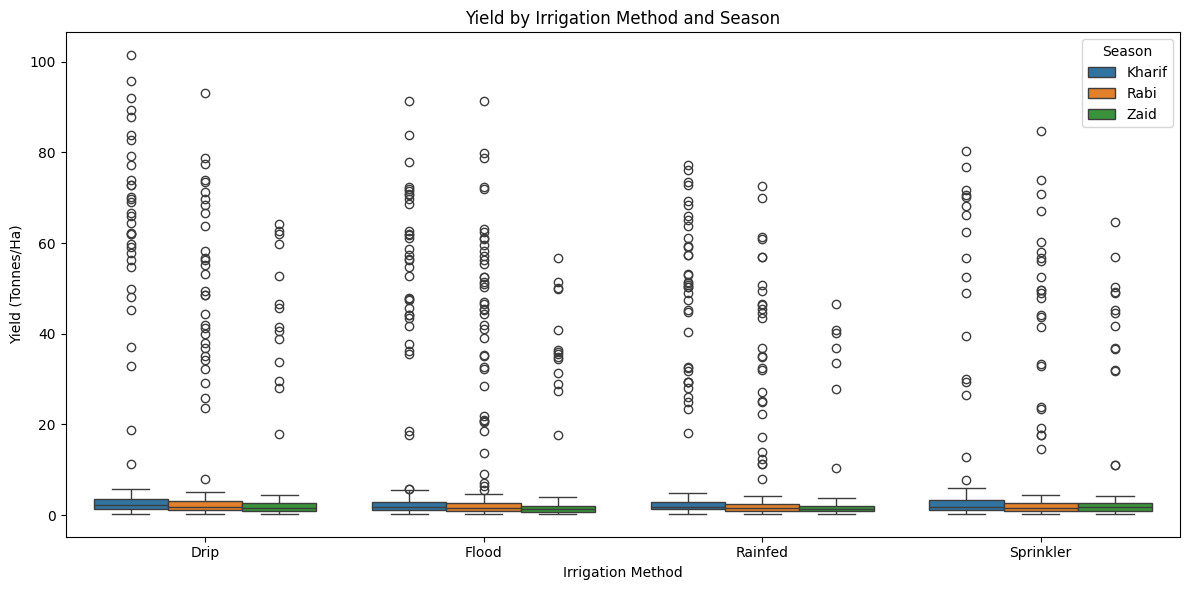

In [ ]:
# Effect of irrigation method and season on yield
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    hue="Season"
)
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

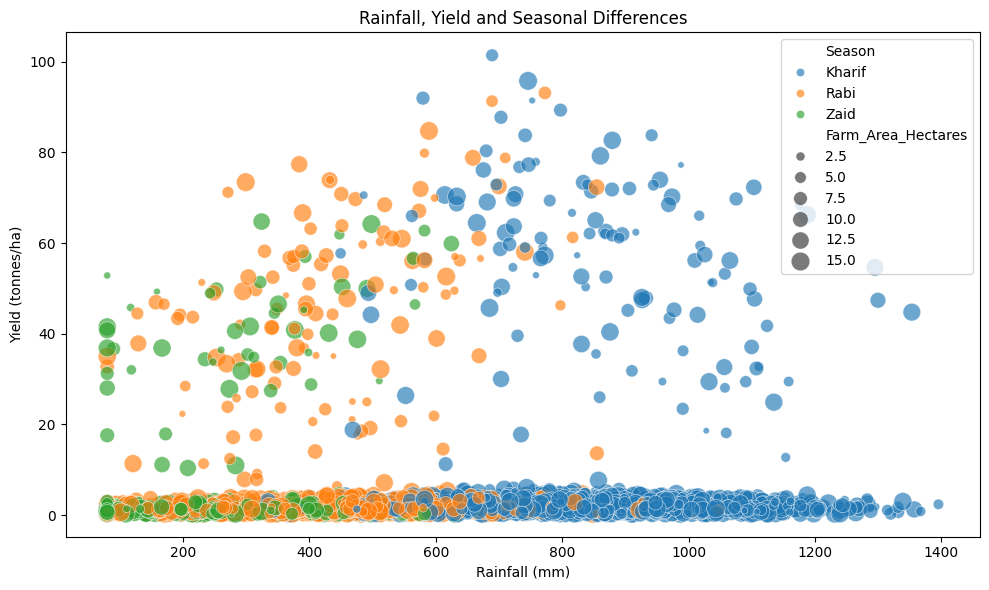

In [ ]:
# Rainfall, yield and season
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65
)
plt.title("Rainfall, Yield and Seasonal Differences")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()


## 12. Correlation Analysis

Correlation analysis is used to examine the relationships between numerical
variables in the agricultural dataset.


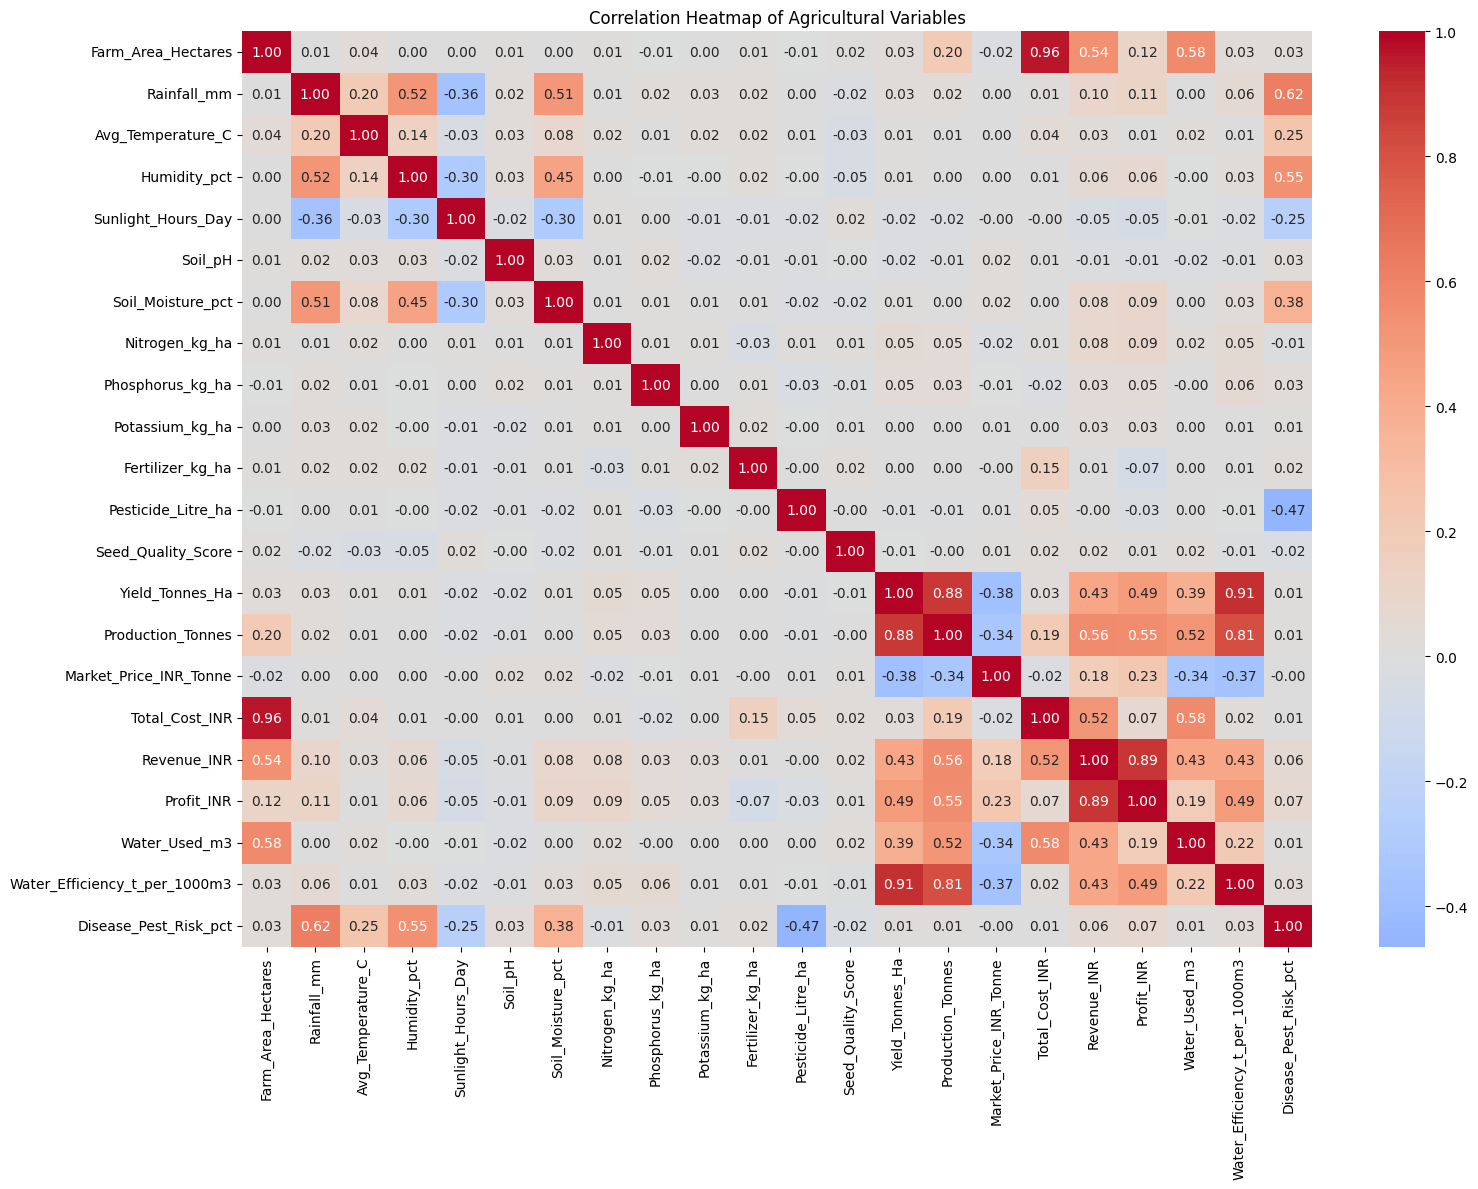

In [ ]:
# Correlation matrix for numerical variables
corr = df[numeric_columns].corr(numeric_only=True)
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap of Agricultural Variables")
plt.tight_layout()
plt.show()

In [ ]:
# Strong correlations between numerical variables
strong_corr = corr.where(
    (abs(corr) >= 0.60) & (abs(corr) < 1)
).stack().sort_values(ascending=False)
strong_corr

,,0
Farm_Area_Hectares,Total_Cost_INR,0.962211
Total_Cost_INR,Farm_Area_Hectares,0.962211
Water_Efficiency_t_per_1000m3,Yield_Tonnes_Ha,0.912568
Yield_Tonnes_Ha,Water_Efficiency_t_per_1000m3,0.912568
Profit_INR,Revenue_INR,0.887331
Revenue_INR,Profit_INR,0.887331
Production_Tonnes,Yield_Tonnes_Ha,0.882813
Yield_Tonnes_Ha,Production_Tonnes,0.882813
Water_Efficiency_t_per_1000m3,Production_Tonnes,0.812143
Production_Tonnes,Water_Efficiency_t_per_1000m3,0.812143


## 13. Seasonal Comparison

Seasonal comparison is performed to understand how agricultural performance
changes across different seasons.


In [ ]:
# Average performance by season
season_summary = df.groupby("Season")[
    ["Yield_Tonnes_Ha", "Production_Tonnes", "Profit_INR",
     "Rainfall_mm", "Water_Used_m3"]
].mean().round(2)

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Rainfall_mm,Water_Used_m3
Season,,,,,
Kharif,5.63,46.31,178914.65,849.20,6102.20
Rabi,5.04,41.49,87689.47,437.62,5846.99
Zaid,4.64,38.89,-24804.82,304.65,6419.89


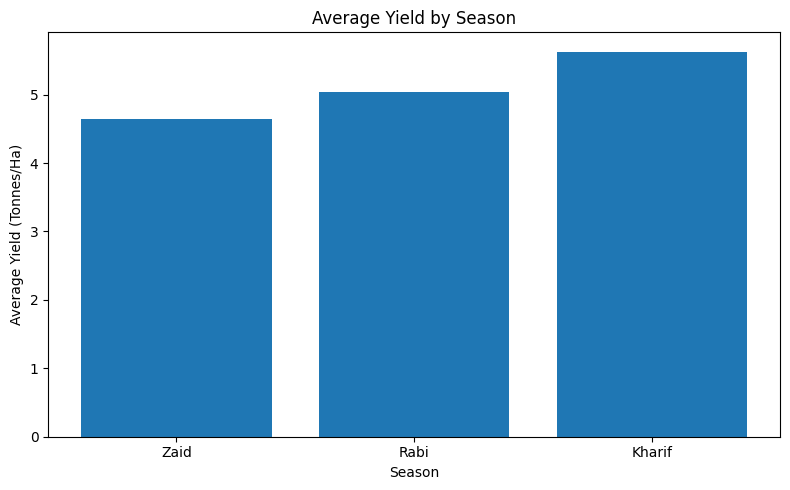

In [ ]:
# Average yield across seasons
plt.figure(figsize=(8, 5))
season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean().sort_values()
plt.bar(season_yield.index, season_yield.values)
plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

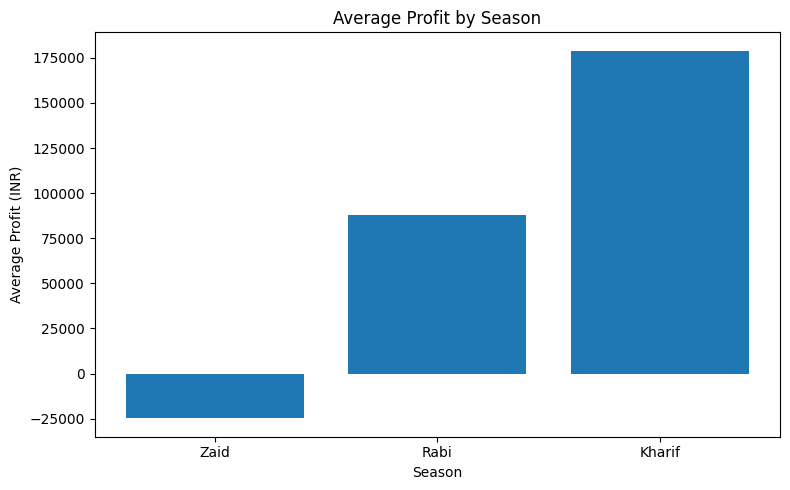

In [ ]:
# Average profit across seasons
plt.figure(figsize=(8, 5))
season_profit = df.groupby("Season")["Profit_INR"].mean().sort_values()
plt.bar(season_profit.index, season_profit.values)
plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

## 14. Student-Designed Analysis

Average Profit by Crop:
Crop
Sugarcane    817187.99
Chilli       750878.34
Cotton       124546.92
Groundnut     44858.12
Pulses        -4238.05
Maize        -83978.33
Rice        -102213.50
Wheat       -123398.34
Name: Profit_INR, dtype: float64


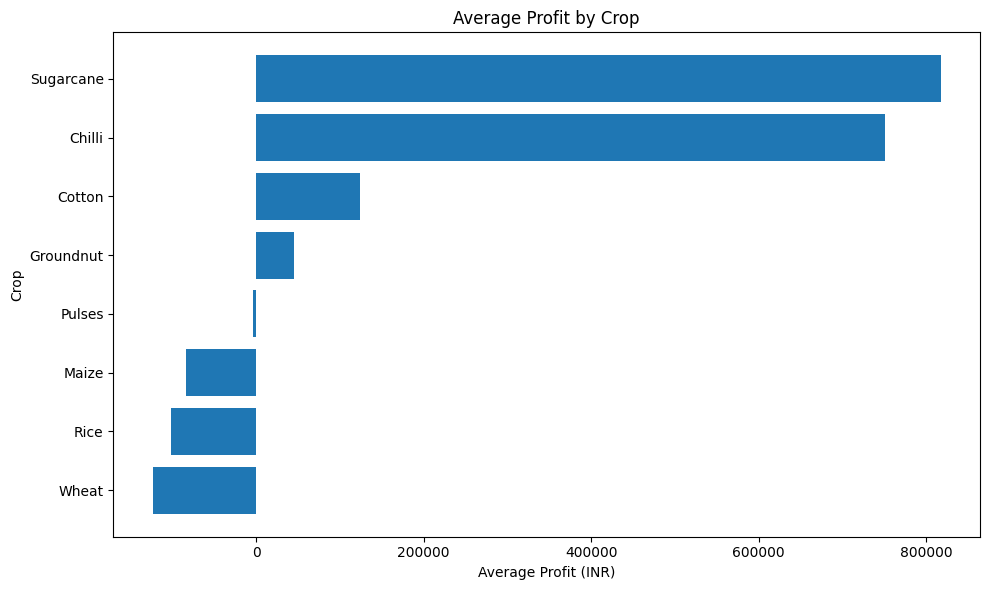

Most profitable crop: Sugarcane
Least profitable crop: Wheat


In [ ]:
# Analysis 1
# Question: Which crops have better average profitability?
# Analysis:
crop_profit = (
    df.groupby("Crop")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)
print("Average Profit by Crop:")
print(crop_profit.round(2))
# Visualization:
plt.figure(figsize=(10, 6))
plt.barh(crop_profit.index, crop_profit.values)
plt.title("Average Profit by Crop")
plt.xlabel("Average Profit (INR)")
plt.ylabel("Crop")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
# Interpretation:
print("Most profitable crop:", crop_profit.idxmax())
print("Least profitable crop:", crop_profit.idxmin())

Correlation between Water Used and Yield: 0.39


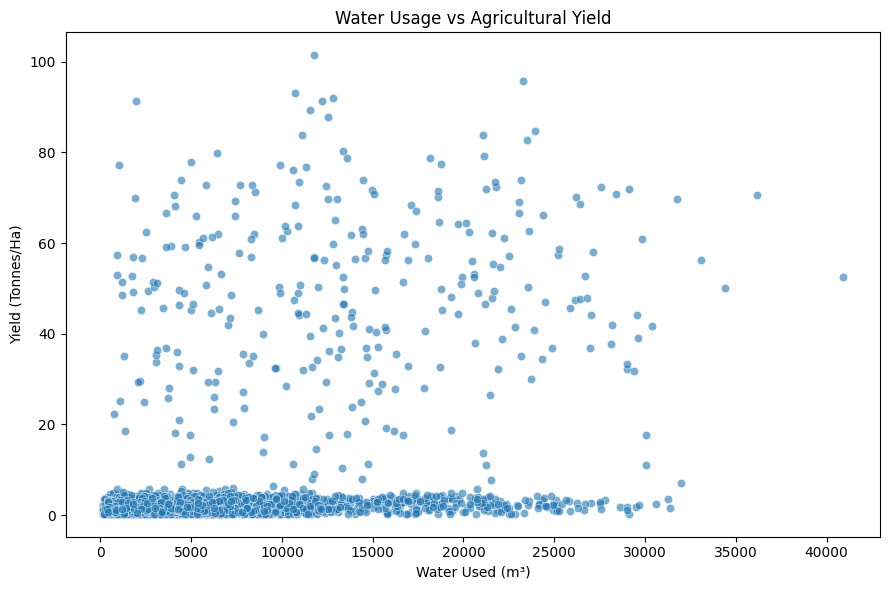

Water usage and yield show a positive relationship.


In [ ]:
# Analysis 2
# Question: Does water usage have a relationship with agricultural yield?
# Analysis:
water_yield_corr = df["Water_Used_m3"].corr(df["Yield_Tonnes_Ha"])

print("Correlation between Water Used and Yield:",
      round(water_yield_corr, 2))
# Visualization:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Water_Used_m3",
    y="Yield_Tonnes_Ha",
    alpha=0.6
)
plt.title("Water Usage vs Agricultural Yield")
plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()
# Interpretation:
if water_yield_corr > 0:
    print("Water usage and yield show a positive relationship.")
elif water_yield_corr < 0:
    print("Water usage and yield show a negative relationship.")
else:
    print("Water usage and yield show no linear relationship.")

Average Yield by State:
State
Punjab            6.12
Karnataka         5.69
Gujarat           5.66
Telangana         5.04
Maharashtra       5.02
Madhya Pradesh    4.99
Tamil Nadu        4.88
Andhra Pradesh    4.63
Name: Yield_Tonnes_Ha, dtype: float64


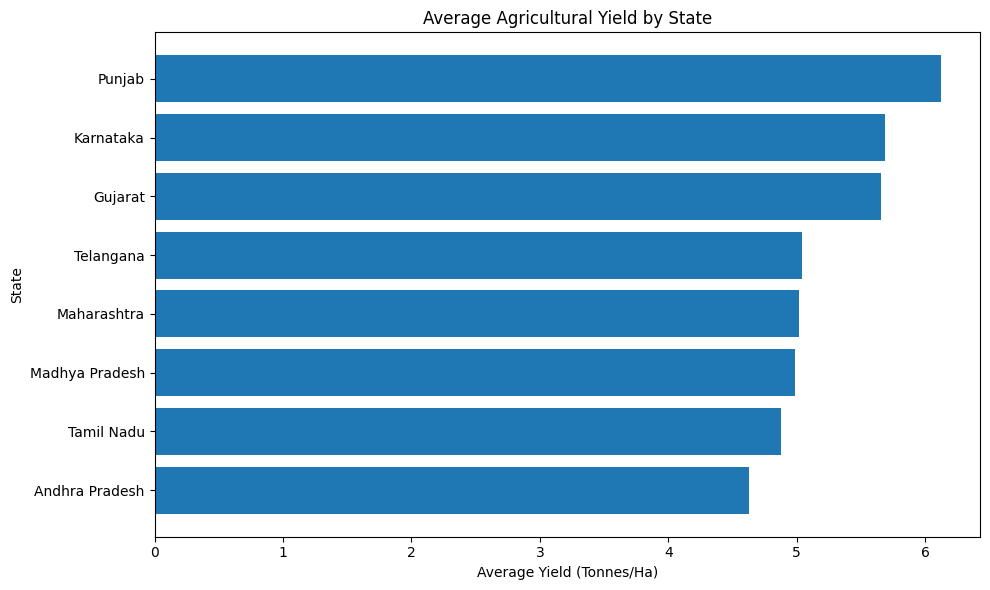

State with highest average yield: Punjab
Highest average yield: 6.12
State with lowest average yield: Andhra Pradesh
Lowest average yield: 4.63


In [ ]:
# Analysis 3
# Question: How does agricultural yield vary across different states?
# Analysis:
state_yield = (
    df.groupby("State")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)
print("Average Yield by State:")
print(state_yield.round(2))
# Visualization:
plt.figure(figsize=(10, 6))
plt.barh(state_yield.index, state_yield.values)
plt.title("Average Agricultural Yield by State")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("State")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
# Interpretation:
print("State with highest average yield:", state_yield.idxmax())
print("Highest average yield:", round(state_yield.max(), 2))
print("State with lowest average yield:", state_yield.idxmin())
print("Lowest average yield:", round(state_yield.min(), 2))

## 14. Key Insights

### 1. Overall data quality

- **Observation:** The dataset has very few missing values and no duplicate records.
- **Evidence:** Missing values were low, with a maximum of 1.2% in Rainfall, and no duplicate rows were found.
- **Interpretation:** The dataset was suitable for further analysis.
- **Limitation:** Basic data checks cannot identify every possible data error.

### 2. Crop profitability differs

- **Observation:** Sugarcane and Chilli have higher average profits, while Wheat and Rice have negative average profits.
- **Evidence:** The crop-wise profit analysis shows clear differences in average Profit_INR.
- **Interpretation:** Crop choice is related to differences in profitability.
- **Limitation:** The results apply only to the crops and farms in this dataset.

### 3. Kharif performs better on average

- **Observation:** Kharif has the highest average yield (5.63 Tonnes/Ha) and profit (₹178,914).
- **Evidence:** Seasonal comparison shows the highest yield and profit values for Kharif. Its average rainfall is also about 849 mm.
- **Interpretation:** Kharif shows better overall performance in the available data.
- **Limitation:** The analysis does not prove that rainfall caused the higher performance.

### 4. Zaid has lower profitability

- **Observation:** Zaid is the only season with negative average profit (-₹24,804).
- **Evidence:** The seasonal profit analysis shows a negative average Profit_INR for Zaid.
- **Interpretation:** Zaid shows weaker average economic performance in this dataset.
- **Limitation:** This does not mean Zaid farming is always unprofitable.

### 5. Yield differs across states

- **Observation:** Punjab has the highest average yield (6.12 Tonnes/Ha), while Andhra Pradesh has 4.63 Tonnes/Ha.
- **Evidence:** The state-wise yield analysis shows differences between the states.
- **Interpretation:** Agricultural performance varies across the studied regions.
- **Limitation:** The analysis does not identify the exact reason for these differences.

### 6. Water usage and yield are related

- **Observation:** Water usage has a positive relationship with yield.
- **Evidence:** The correlation between water usage and yield is 0.39, while water efficiency and yield have a correlation of 0.91.
- **Interpretation:** Water-related factors are associated with yield in this dataset.
- **Limitation:** Correlation does not prove that increasing water usage will increase yield.

### 7. Farm area and cost are strongly related

- **Observation:** Farm area and total cost have a very strong positive relationship.
- **Evidence:** Their correlation is 0.96.
- **Interpretation:** Larger farming operations are generally associated with higher total costs.
- **Limitation:** Farm size is not the only factor that can affect total cost.

### 8. Rainfall and disease risk are related

- **Observation:** Rainfall and disease/pest risk show a positive relationship.
- **Evidence:** Their correlation is 0.62.
- **Interpretation:** Higher rainfall values are associated with higher recorded disease/pest risk.
- **Limitation:** The result does not prove that rainfall alone causes disease or pest problems.

## 15. Recommendations

1. **Consider crop profitability:** Crops with better average profits can be considered when comparing different crop options. However, costs and local conditions should also be checked before making a decision.

2. **Plan according to seasonal performance:** Since yield and profit vary across seasons, seasonal performance can be considered while planning farming activities.

3. **Use water carefully:** The relationship between water usage and yield shows that water management is an important area to study. Water use should be monitored rather than increased without considering other factors.

4. **Pay attention to regional differences:** Since average yield differs between states, local farming conditions and practices should be considered when comparing agricultural performance.

5. **Monitor disease and pest risk:** The positive relationship between rainfall and disease/pest risk suggests that disease and pest conditions should be monitored during periods with higher rainfall.



## 16. Limitations

1. This analysis is based on the data available in the dataset, so the results may not represent every farm or region.

2. A few missing values were present in the dataset. These were handled during data cleaning, but they may still have a small effect on the results.

3. The analysis mainly shows relationships between variables. It does not prove that one variable directly causes a change in another.

4. Agricultural performance can depend on many factors. Some factors, such as detailed soil conditions, farmer practices, weather changes, and market conditions, are not fully covered in this dataset.

5. Some unusual values were found during the outlier analysis. They were not removed because they could represent real farming conditions.

## 16. Conclusion

This project helped to understand how agricultural performance changes across
different seasons, crops, and regions. From the analysis, we found differences
in yield and profit across seasons, crops, and states. Kharif showed the highest
average yield and profit in this dataset, while Zaid had a negative average
profit.

Also found some useful relationships between variables. Water usage and
yield showed a positive relationship, while farm area and total cost had a very
strong relationship. Rainfall and disease/pest risk also showed a positive
relationship.

Overall, the analysis shows that agricultural performance depends on several
factors and cannot be judged using only one variable. The results can be useful
for comparing farming conditions, understanding resource usage, and identifying
areas that may need more attention.

At the same time, the findings are limited to the data available in this
project. More detailed data and analysis over a longer period could give a
better understanding of agricultural performance and help in making more
reliable decisions in the future.